In [26]:
import pandas as pd

df = pd.read_csv('spotify.csv')
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [27]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

In [29]:
# Extracted the features needed
features = df[['energy', 'danceability', 'valence', 'tempo', 'loudness']]
features.head()

,energy,danceability,valence,tempo,loudness
0,0.910,0.389,0.814,166.969,-1.828
1,0.737,0.590,0.816,174.003,-5.559
2,0.131,0.663,0.368,99.488,-13.879
3,0.326,0.240,0.227,171.758,-12.178
4,0.225,0.331,0.390,140.576,-21.150


In [30]:
# Data cleaning
features = features.dropna()

In [31]:
# Data Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [32]:
# Apply k-means
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [33]:
# Add cluster labels
features['cluster'] = clusters
features

,energy,danceability,valence,tempo,loudness,cluster
0,0.910,0.389,0.814,166.969,-1.828,2
1,0.737,0.590,0.816,174.003,-5.559,2
2,0.131,0.663,0.368,99.488,-13.879,0
3,0.326,0.240,0.227,171.758,-12.178,0
4,0.225,0.331,0.390,140.576,-21.150,1
...,...,...,...,...,...,...
232720,0.714,0.687,0.962,115.542,-10.626,3
232721,0.683,0.785,0.969,113.830,-6.944,3
232722,0.419,0.517,0.813,84.135,-8.282,3
232723,0.704,0.745,0.489,100.031,-7.137,3


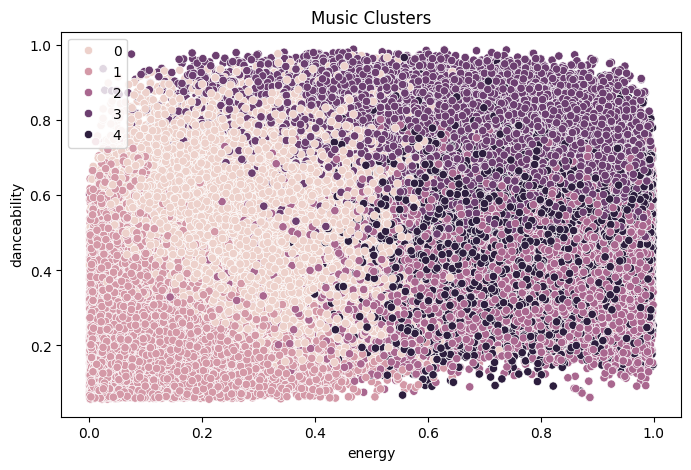

In [34]:
# vizualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x=features['energy'], y=features['danceability'], hue=clusters)
plt.title("Music Clusters")
plt.show()

In [35]:
features.groupby('cluster').mean()

,energy,danceability,valence,tempo,loudness
cluster,,,,,
0,0.363649,0.558582,0.328522,114.804062,-11.856957
1,0.134341,0.265238,0.132196,98.652256,-21.359480
2,0.751289,0.503520,0.505394,160.012168,-6.134783
3,0.666534,0.727116,0.733104,111.974085,-7.317571
4,0.749618,0.548222,0.371678,100.064440,-6.320722


In [36]:
# assigning meaningful labels to the clusters
cluster_map = {
    0: 'Chill',
    1: 'Sad',
    2: 'Energetic',
    3: 'Happy',
    4: 'Aggressive'
}

features['music_type'] = features['cluster'].map(cluster_map)
features

,energy,danceability,valence,tempo,loudness,cluster,music_type
0,0.910,0.389,0.814,166.969,-1.828,2,Energetic
1,0.737,0.590,0.816,174.003,-5.559,2,Energetic
2,0.131,0.663,0.368,99.488,-13.879,0,Chill
3,0.326,0.240,0.227,171.758,-12.178,0,Chill
4,0.225,0.331,0.390,140.576,-21.150,1,Sad
...,...,...,...,...,...,...,...
232720,0.714,0.687,0.962,115.542,-10.626,3,Happy
232721,0.683,0.785,0.969,113.830,-6.944,3,Happy
232722,0.419,0.517,0.813,84.135,-8.282,3,Happy
232723,0.704,0.745,0.489,100.031,-7.137,3,Happy


In [37]:
# Simulating the user
user_input = [[0.8, 0.7, 0.6, 120, -5]]  # energy, danceability, valence, tempo, loudness
user_scaled = scaler.transform(user_input) #scaling the user input

user_cluster = kmeans.predict(user_scaled)

c:\Users\windows@priyanshu18\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [38]:
print("User belongs to cluster:", user_cluster[0])

User belongs to cluster: 3


In [39]:
# cluster to music-type
user_music_type = cluster_map[user_cluster[0]]
print("Music Type:", user_music_type)

Music Type: Happy


In [40]:
# Music to personality mapping with descriptions
personality_map = {
    "The High-Energy Type": ("The High-Energy Type", "You like to stay active and enjoy fast-paced vibes."),
    "The Relaxed Soul": ("The Relaxed Soul", "You prefer a calm environment and peaceful music."),
    "The Positive Spirit": ("The Positive Spirit", "You have an optimistic outlook and love feel-good music."),
    "The Deep Thinker": ("The Deep Thinker", "You connect deeply with emotions and meaningful lyrics."),
    "The Intense Personality": ("The Intense Personality", "You are bold and enjoy music with power and impact.")
}

# Getting the result (if nothing found then Hard-coded data will be shown)
personality_data = personality_map.get(user_music_type, ("Music Lover", "You enjoy a wide variety of musical styles."))

label = personality_data[0]
description = personality_data[1]

print(f"Personality: {label}")
print(f"Description: {description}")

Personality: Music Lover
Description: You enjoy a wide variety of musical styles.


In [41]:
# Now labelling the dataset for creating classification models for predicting personality
def get_personality(music_type):
    if music_type == "Energetic":
        return "The High-Energy Type"
    elif music_type == "Chill":
        return "The Relaxed Soul"
    elif music_type == "Happy":
        return "The Positive Spirit"
    elif music_type == "Sad":
        return "The Deep Thinker"
    else:
        return "The Intense Personality"

features['personality'] = features['music_type'].apply(get_personality)

In [42]:
X = scaled_data   # IMPORTANT (scaled use karo)
y = features['personality']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [46]:
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, knn.predict(X_test)))
print("NB Accuracy:", accuracy_score(y_test, nb.predict(X_test)))

KNN Accuracy: 0.9752712428832313
NB Accuracy: 0.9363411752067892


In [47]:
user_input = [[0.8, 0.7, 0.6, 120, -5]]
user_scaled = scaler.transform(user_input)

predicted_personality = knn.predict(user_scaled)[0]
print("Predicted Personality:", predicted_personality)

Predicted Personality: The Positive Spirit


c:\Users\windows@priyanshu18\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [48]:
personality_data = personality_map.get(
    predicted_personality,
    ("Music Lover", "You enjoy a wide variety of musical styles.")
)

label = personality_data[0]
description = personality_data[1]

print(f"Personality: {label}")
print(f"Description: {description}")

Personality: The Positive Spirit
Description: You have an optimistic outlook and love feel-good music.
